In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
try:
    df = pd.read_csv('diamonds.csv')
except FileNotFoundError:
    sns.load_dataset('diamonds').to_csv("diamonds.csv")
    df = pd.read_csv('diamonds.csv')

In [3]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


| **Diamonds** | `pd.read_csv("diamonds.csv")` | 53,940 diamonds and their price | What makes a diamond expensive? |

- **Diamonds:** `carat` (weight), `cut` (quality of the cutting: Fair → Ideal), `color` (D = best → J), `clarity` (how clean inside: I1 = worst → IF = best), `price` (in dollars), `x`, `y`, `z` (length, width, depth in mm), `depth` and `table` (shape measurements in %). Big dataset: charts can be slow.

In [4]:
df.shape

(53940, 10)

In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [7]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [8]:

print(df['cut'].value_counts())


cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64


In [9]:
print(df['clarity'].value_counts())


clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [10]:
df['carat'].max()

np.float64(5.01)

In [11]:
df['carat'].mean()

np.float64(0.7979397478680014)

In [12]:
df['color'].value_counts()


color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [13]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

no null values

now we have to merge x,y,z as volume to make it better

In [14]:
print(((df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)).sum()) 

df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
df = df[(df['y'] < 20) & (df['z'] < 20)]
df = df.reset_index(drop=True)
df["volume"] = df["x"] * df["y"] * df["z"]

20


set string values columns into numeric form
cut: Fair=1, Good=2, Very Good=3, Premium=4, Ideal=5
color: J=1, I=2, H=3, G=4, F=5, E=6, D=7
clarity: I1=1, SI2=2, SI1=3, VS2=4, VS1=5, VVS2=6, VVS1=7, IF=8

In [15]:
df['cut'] = np.where(df['cut'] == 'Fair', 1,
                 np.where(df['cut'] == 'Good', 2,
                 np.where(df['cut'] == 'Very Good', 3,
                 np.where(df['cut'] == 'Premium', 4,
                 np.where(df['cut'] == 'Ideal', 5, np.nan)))))

In [16]:
df['color'] = np.where(df['color'] == 'J', 1,
                np.where(df['color'] == 'I', 2,
                 np.where(df['color'] == 'H', 3,
                 np.where(df['color'] == 'G', 4,
                 np.where(df['color'] == 'F', 5,
                 np.where(df['color'] == 'E', 6,  
                 np.where(df['color'] == 'D', 7,       
                          np.nan)))))))

In [17]:
df['clarity'] = np.where(df['clarity'] == 'I1',1,
                np.where(df['clarity'] == 'SI2',2,
                 np.where(df['clarity'] == 'SI1' ,3,
                 np.where(df['clarity'] == 'VS2',4,
                 np.where(df['clarity'] == 'VS1',5,
                 np.where(df['clarity'] == 'VVS2',6,  
                 np.where(df['clarity'] == 'VVS1',7,
                 np.where(df['clarity'] == 'IF',8,     
                          np.nan))))))))

after converting we have extra columns now we have to remove some extras columns like x,y,z, cut,clarity,color 

In [18]:
df.head(2)

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
0,0.23,5.0,6.0,2.0,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,4.0,6.0,3.0,59.8,61.0,326,3.89,3.84,2.31,34.505856


In [19]:
df = df.drop(columns=['x','y','z'])

In [20]:
# after drop we have all numeric data and add new colums
df.head()

,carat,cut,color,clarity,depth,table,price,volume
0,0.23,5.0,6.0,2.0,61.5,55.0,326,38.202030
1,0.21,4.0,6.0,3.0,59.8,61.0,326,34.505856
2,0.23,2.0,6.0,5.0,56.9,65.0,327,38.076885
3,0.29,4.0,2.0,4.0,62.4,58.0,334,46.724580
4,0.31,2.0,1.0,2.0,63.3,58.0,335,51.917250


In [21]:
df.shape  

(53917, 8)

In [22]:
print(df.duplicated().sum())


145


In [23]:
df = df.drop_duplicates()

In [24]:
df.shape

(53772, 8)

In [25]:
df['volume'].describe()

count    53772.000000
mean       129.777480
std         76.360280
min         31.707984
25%         65.208338
50%        114.852720
75%        170.834047
max        790.133208
Name: volume, dtype: float64

<Axes: xlabel='volume'>

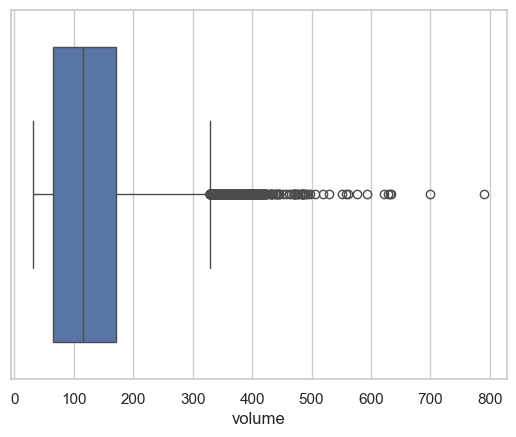

In [26]:
sns.boxplot(data=df, x='volume')

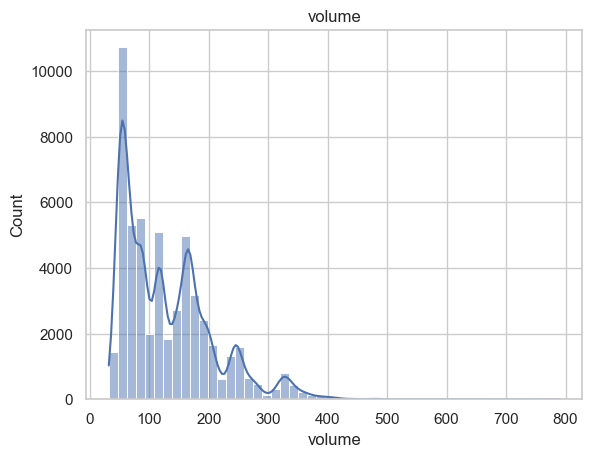

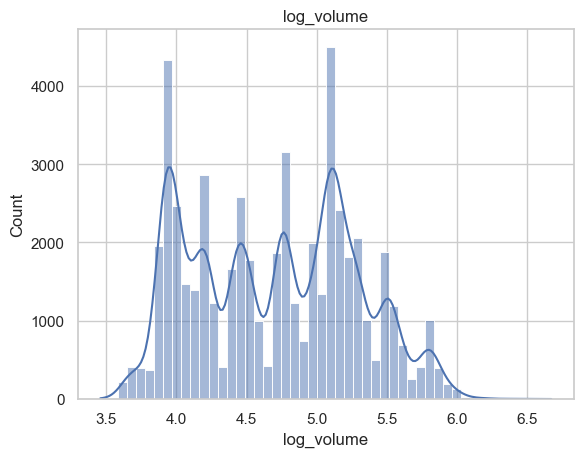

In [27]:
df["log_volume"] = np.log(df["volume"])

sns.histplot(df["volume"], bins=50,kde=True)
plt.title("volume")
plt.show()
sns.histplot(df["log_volume"], bins=50, kde=True)
plt.title("log_volume")
plt.show()

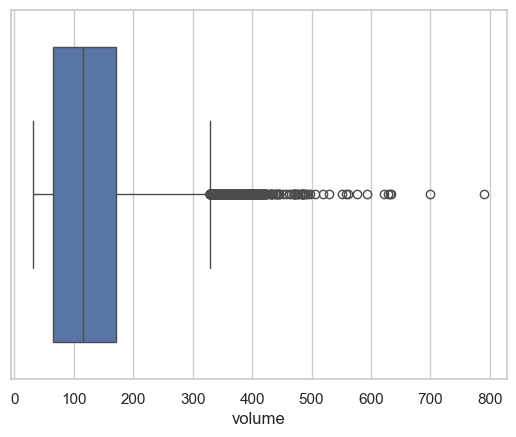

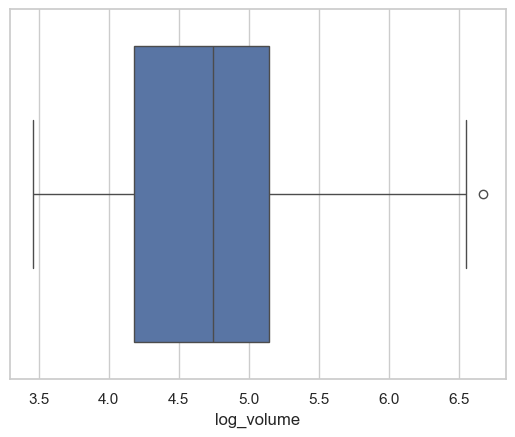

count    53772.000000
mean         4.700078
std          0.578359
min          3.456569
25%          4.177587
50%          4.743651
75%          5.140693
max          6.672202
Name: log_volume, dtype: float64

In [28]:
sns.boxplot(data=df, x='volume')
plt.show()
sns.boxplot(data=df, x='log_volume')
plt.show()
df['log_volume'].describe()

In [29]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
high = q3 + 1.5 * iqr
high

outliers = df[df['price']>high]
len(outliers)

3519

<Axes: xlabel='price'>

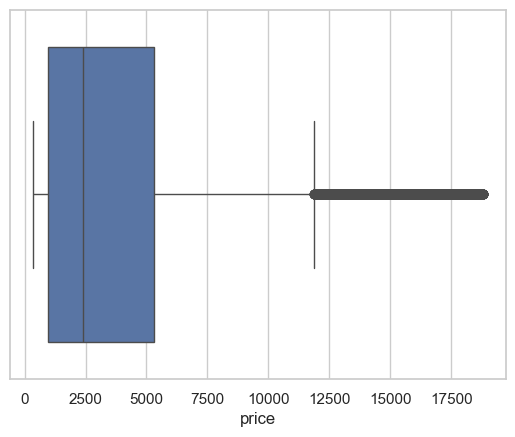

In [30]:
sns.boxplot(data=df,x='price')

In [31]:
df["log_price"] = np.log(df["price"])

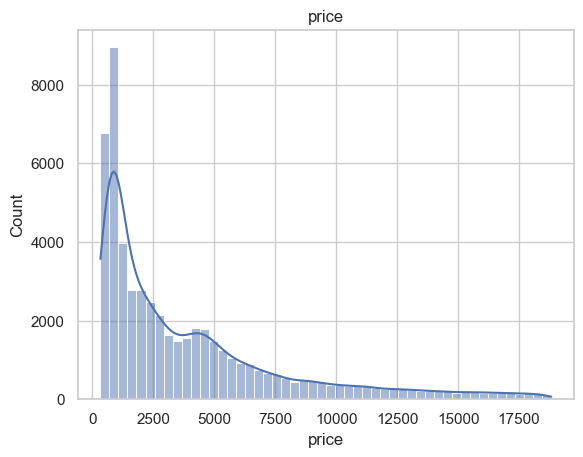

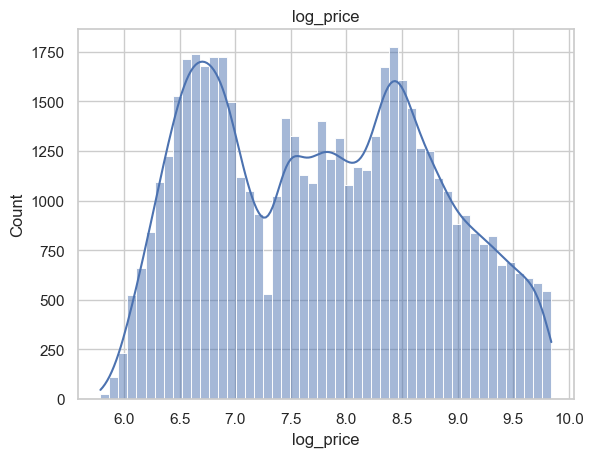

In [32]:
sns.histplot(df["price"], bins=50,kde=True)
plt.title("price")
plt.show()
sns.histplot(df["log_price"], bins=50, kde=True)
plt.title("log_price")
plt.show()

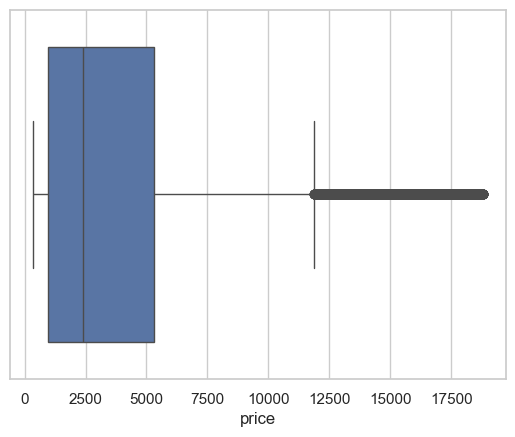

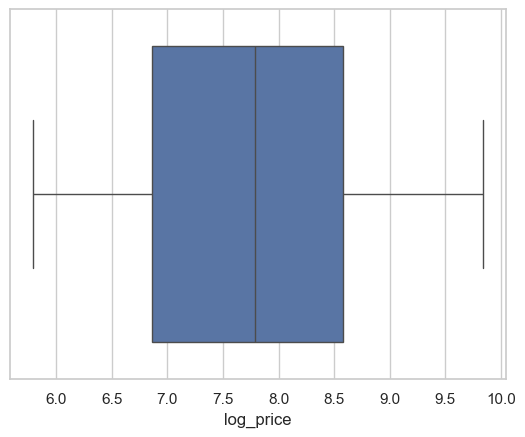

count    53772.000000
mean      3931.137321
std       3985.853004
min        326.000000
25%        951.000000
50%       2401.000000
75%       5324.000000
max      18823.000000
Name: price, dtype: float64

In [33]:
sns.boxplot(data=df, x='price')
plt.show()
sns.boxplot(data=df, x='log_price')
plt.show()
df['price'].describe()

In [34]:
df['log_price'].describe()

count    53772.000000
mean         7.786735
std          1.014324
min          5.786897
25%          6.857514
50%          7.783641
75%          8.579980
max          9.842835
Name: log_price, dtype: float64

<Axes: xlabel='carat'>

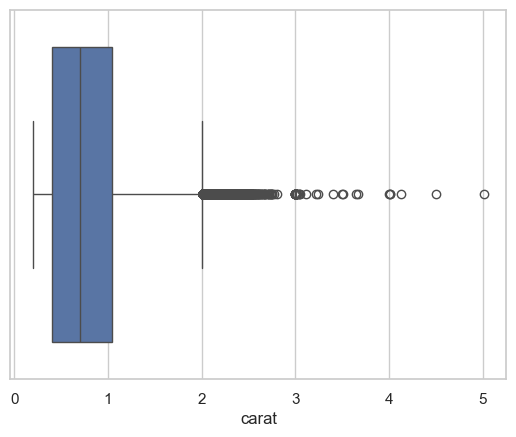

In [35]:
sns.boxplot(data=df, x='carat')

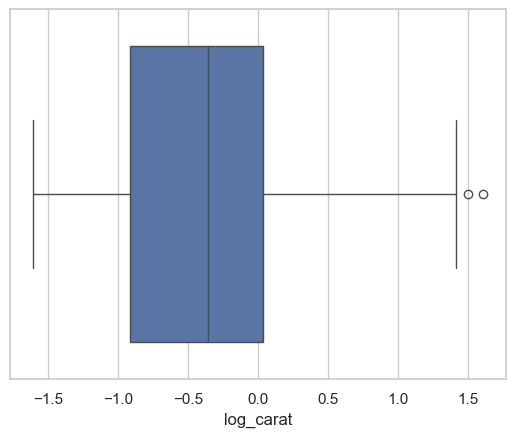

In [36]:
df["log_carat"] = np.log(df["carat"])
sns.boxplot(data=df,x='log_carat')
plt.show()

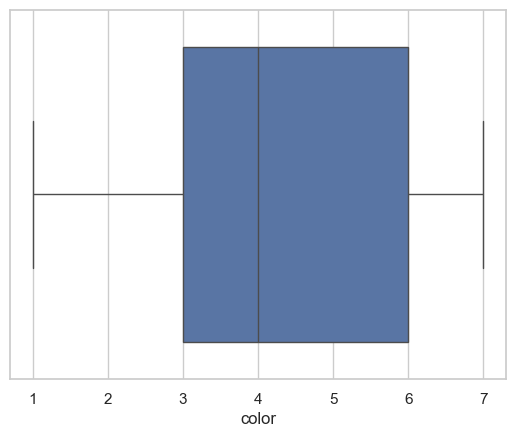

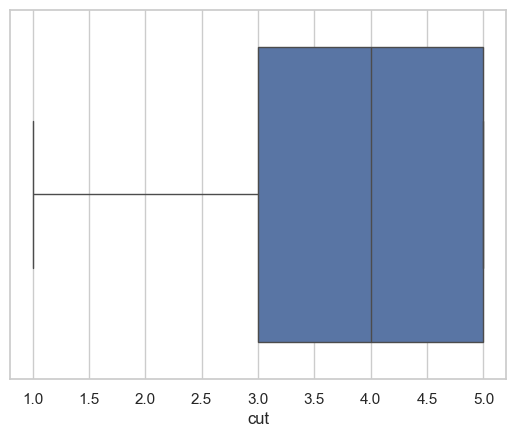

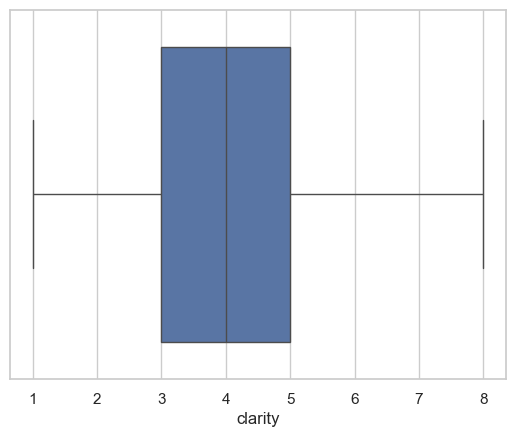

In [45]:
sns.boxplot(data=df,x='color')
plt.show()
sns.boxplot(data=df,x='cut')
plt.show()
sns.boxplot(data=df,x='clarity')
plt.show()


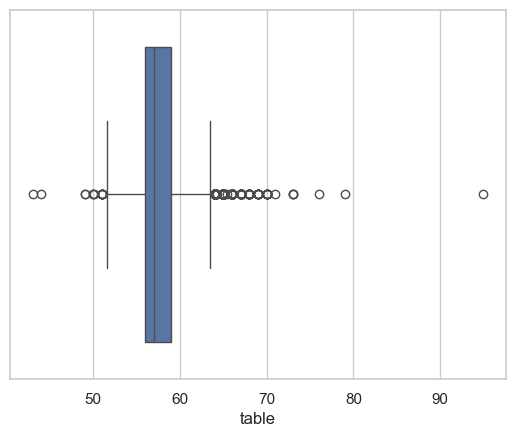

In [53]:
sns.boxplot(data=df,x='table')
plt.show()

In [52]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'volume',
       'log_volume', 'log_price', 'log_carat'],
      dtype='object')

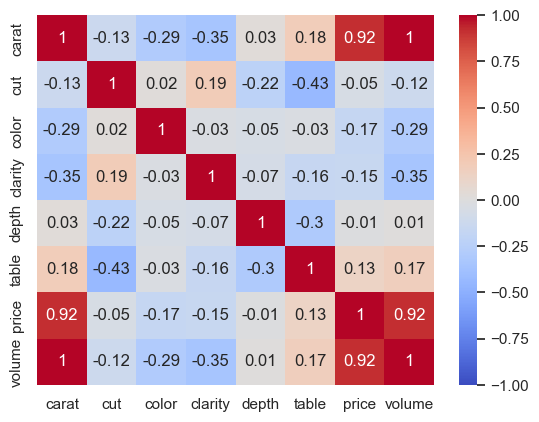

In [38]:
cols=['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'volume',]

plt.Figure(figsize=(7,5))
sns.heatmap(df[cols].corr().round(2), annot=True, cmap='coolwarm',vmin=-1,vmax=1)
plt.show()

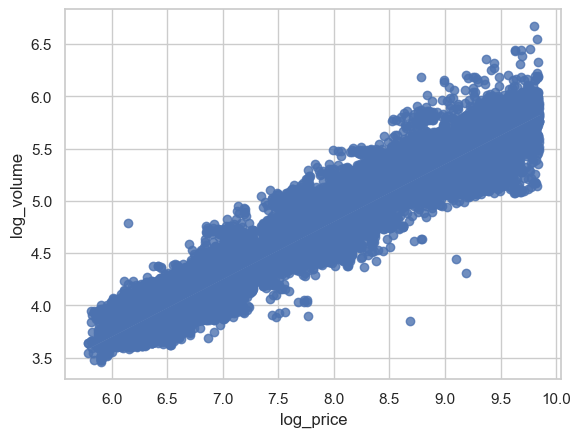

In [39]:
sns.regplot(data=df,x='log_price',y='log_volume')
plt.show()

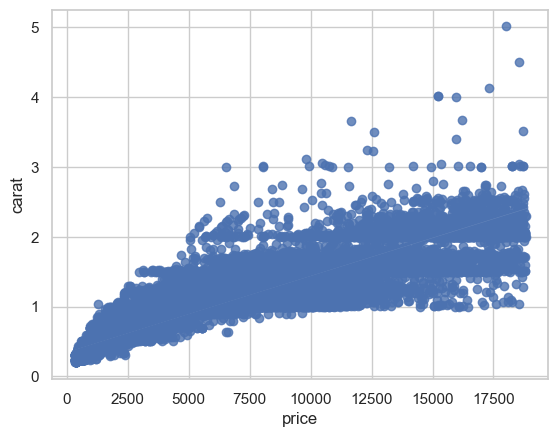

In [43]:
sns.regplot(data=df,x='price',y='carat')
plt.show()